## Basic Pipeline — Establish a Clean Baseline

Start with **char-level chunking**, simple **vector retrieval with a small `k` (e.g., 3)**, and **no reranking**. Each chunk is treated as a single unit of meaning, which makes the system easy to debug because retrieved results directly map to something human-readable (a page). A small `top_k` ensures high precision — the model only sees the most relevant chunks, reducing noise and making it easier to understand failure cases. We intentionally avoid reranking here to isolate the raw performance of embeddings + retrieval. This setup answers the question: *“Can basic semantic retrieval find the right page and produce a grounded answer?”*  
This is your control — simple, interpretable, and essential for comparison.

- **Always return answers with citations** to enforce grounding and make evaluation easier.

## RAG Evaluation Metrics

- **Relevance (rule-based)** — atleast one of retrieved chunks are relevant → true/false
- **Groundedness (LLM judge)** — all claims are supported by retrieved context → true/false
- **Answer Correctness (LLM judge)** — answer matches key facts in sample answer → true/false

### Libraries

In [1]:
import pandas as pd
from typing import Any
from langchain_community.document_loaders import PyPDFLoader
import pprint
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
import shutil
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama
import matplotlib.pyplot as plt
import seaborn as sns
import random

### Benchmark Data

In [2]:
# create benchmark data
benchmark_data = [

    {
      "question": "What renewed the interest of Machine Learning?",
      "answer": "The success of Deep Learning",
      "group": "lookup"
    }, 

    {
      "question": "What type of features are typically produced through batch processing and stream processing in ML systems?",
      "answer": "Batch processing typically produces static features that change slowly, while stream processing produces dynamic features that change rapidly in real time.",
      "group": "lookup"
    },

    {
      "question": "What is stratified sampling and why is it used?",
      "answer": "Stratified sampling is a method where the population is divided into groups (strata) and samples are taken from each group separately. It is used to ensure that all important groups are represented in the sample.",
      "group": "lookup"
    }, 

    {
      "question": "How do machine learning systems differ from traditional software systems, and what challenges do they introduce?",
      "answer": "Machine learning systems differ from traditional software systems in both how they are built and the challenges they introduce. Traditional software typically relies on explicitly programmed rules and modular separation between code and data, whereas ML systems learn patterns directly from data. This makes ML especially useful for complex tasks such as object detection or language understanding, where manually defining rules would be impractical. Unlike research-focused ML, production ML systems must operate reliably under real-world constraints such as scalability, latency, monitoring, and changing data distributions. As a result, ML systems require specialized tooling for data management, model training, deployment, evaluation, and continuous improvement. Because behavior is driven by both code and learned parameters from data, ML systems are often referred to as Software 2.0.",
      "group": "conceptual"
    },

    {
      "question": "What is the difference between multiclass and multilabel classification, and what challenges does multilabel classification introduce?",
      "answer": "In multiclass classification, each example belongs to exactly one class, whereas in multilabel classification an example can belong to multiple classes simultaneously. Multilabel problems can be handled either by using multi-hot label representations or by training separate binary classifiers for each class. However, multilabel classification is more challenging because annotation can be inconsistent when annotators disagree on applicable labels, and prediction is harder since the model must determine how many labels to assign rather than selecting just one, making probability interpretation and thresholding more complex.",
      "group": "conceptual"
    },

    {
      "question": "What is sampling in machine learning, why is it important, and what are its main types?",
      "answer": "Sampling is important in machine learning for managing data size, reducing bias, and improving efficiency. The two main families are nonprobability sampling (e.g., convenience sampling) and random sampling (e.g., reservoir sampling and importance sampling). Effective sampling helps create more representative datasets while optimizing resource usage.",
      "group": "conceptual"
    },

    {
      "question": "What are the four key requirements of a production ML system, and what does each requirement mean?",
      "answer": "Most ML systems should satisfy four key requirements: reliability, scalability, maintainability, and adaptability. Reliability means the system continues functioning correctly even under failures or adverse conditions. Scalability allows the system to handle growth in data, traffic, and model complexity. Maintainability supports collaboration, reproducibility, and easier debugging through structured workflows and tooling. Adaptability enables the system to evolve as data distributions and business requirements change over time.",
      "group": "long-context"
    },

    {
      "question": "How do batch processing and stream processing differ, what types of ML features does each support, and why is stream processing important in modern ML systems?",
      "answer": "Batch processing operates on historical data stored in databases, data lakes, or warehouses and typically runs periodically using systems like MapReduce or Spark. It is commonly used to compute slowly changing or static features, such as driver ratings. Stream processing operates on continuously arriving data from systems like Kafka or Kinesis and processes data in real time or near real time using engines such as Apache Flink, KSQL, or Spark Streaming. It is used to compute rapidly changing or dynamic features, such as live demand, available drivers, or recent prices. Stream processing is important because it enables low-latency computation, supports stateful incremental updates without repeatedly recomputing entire datasets, and allows ML systems to react quickly to changing conditions. Modern ML systems often combine both batch and streaming features, requiring infrastructure capable of processing and joining both data types.",
      "group": "long-context"
    },

    {
      "question": "What factors determine whether an ML feature generalizes well to unseen data, and what trade-offs can arise when designing more generalizable features?",
      "answer": "A feature generalizes well when it remains useful on unseen data instead of only fitting the training data. Important factors include feature coverage and whether feature values are consistent across train and test data. Features that are too specific may improve accuracy on training data but perform poorly on new data.",
      "group": "long-context"
    },
    
    {
      "question": "Who is Aristotle?",
      "answer": "I cannot answer this question as it is out of my knowledge.",
      "group": "external"
    },
    
    {
      "question": "What is inflation?",
      "answer": "I cannot answer this question as it is out of my knowledge.",
      "group": "external"
    },
    
    {
      "question": "Why did the Industrial Revolution lead to urbanization?",
      "answer": "I cannot answer this question as it is out of my knowledge.",
      "group": "external"
    }
]

# create dataframe for benchmark data
df_benchmark = pd.DataFrame(benchmark_data).reset_index(names="question_id")

df_benchmark

,question_id,question,answer,group
0,0,What renewed the interest of Machine Learning?,The success of Deep Learning,lookup
1,1,What type of features are typically produced t...,Batch processing typically produces static fea...,lookup
2,2,What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup
3,3,How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual
4,4,What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual
5,5,"What is sampling in machine learning, why is i...",Sampling is important in machine learning for ...,conceptual
6,6,What are the four key requirements of a produc...,Most ML systems should satisfy four key requir...,long-context
7,7,How do batch processing and stream processing ...,Batch processing operates on historical data s...,long-context
8,8,What factors determine whether an ML feature g...,A feature generalizes well when it remains use...,long-context
9,9,Who is Aristotle?,I cannot answer this question as it is out of ...,external


### Data Loading

In [3]:
file_path = "../data/books/Designing Machine Learning Systems; An Iterative Process for Production.pdf"
loader = PyPDFLoader(file_path)
document = loader.load()

print("\n\nSample page metadata")
pprint.pp(document[100].metadata)

print("\n\n==============\n\n")

print("Sample page content")
print(document[100].page_content)

Ignoring wrong pointing object 25 0 (offset 0)
Ignoring wrong pointing object 38 0 (offset 0)
Ignoring wrong pointing object 134 0 (offset 0)
Ignoring wrong pointing object 249 0 (offset 0)
Ignoring wrong pointing object 407 0 (offset 0)
Ignoring wrong pointing object 447 0 (offset 0)
Ignoring wrong pointing object 1239 0 (offset 0)




Sample page metadata
{'producer': 'macOS Version 15.3.2 (Build 24D81) Quartz PDFContext',
 'creator': 'AH CSS Formatter V7.1 MR2 for Linux64 : 7.1.3.50324 '
            '(2021-04-26T09:47+09)',
 'creationdate': "D:20260428192210Z00'00'",
 'title': 'Designing Machine Learning Systems',
 'author': 'Huyen, Chip;',
 'moddate': "D:20260428192210Z00'00'",
 'source': '../data/books/Designing Machine Learning Systems; An Iterative '
           'Process for Production.pdf',
 'total_pages': 389,
 'page': 100,
 'page_label': '101'}




Sample page content
CHAPTER 4
Training Data
In Chapter 3, we covered how to handle data from the systems perspective. In this
chapter, we’ll go over how to handle data from the data science perspective. Despite
the importance of training data in developing and improving ML models, ML curric!
ula are heavily skewed toward modeling, which is considered by many practitioners
the “fun” part of the process. Building a state-of-the-art model is interesting. Spend!
ing 

### Chunking

In [4]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(document)

print(f"Length of chunks: {len(chunks)}")

print("\n\n==============\n\n")

print("Sample chunk")
chunks[100]

Length of chunks: 1158




Sample chunk


Document(metadata={'producer': 'macOS Version 15.3.2 (Build 24D81) Quartz PDFContext', 'creator': 'AH CSS Formatter V7.1 MR2 for Linux64 : 7.1.3.50324 (2021-04-26T09:47+09)', 'creationdate': "D:20260428192210Z00'00'", 'title': 'Designing Machine Learning Systems', 'author': 'Huyen, Chip;', 'moddate': "D:20260428192210Z00'00'", 'source': '../data/books/Designing Machine Learning Systems; An Iterative Process for Production.pdf', 'total_pages': 389, 'page': 33, 'page_label': '34'}, page_content='14It’s not unusual for the ML and data science teams to be among the first to go during a company’s mass\nlayoff, as has been reported at IBM, Uber, Airbnb. See also Sejuti Das’s analysis “How Data Scientists Are Also\nSusceptible to the Layoffs Amid Crisis, ” Analytics India Magazine, May 21, 2020, https://oreil.ly/jobmz.\n15Wikipedia, s.v. “Ensemble learning, ” https://oreil.ly/5qkgp.\nML platform team\nAs the traffic grows, this team has been woken up in the middle of the night\nbecause of pro

### Data Indexing

In [5]:
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    encode_kwargs={"normalize_embeddings": True},
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [6]:
# vector db path
db_path = "../data/chroma_db"

# remove old db
shutil.rmtree(db_path, ignore_errors=True)

# create vector store
vector_store = Chroma(
    collection_name="ml_book",
    embedding_function=embeddings,
    persist_directory=db_path,
)

# stable ids
ids = [str(i) for i in range(len(chunks))]

# add documents
vector_store.add_documents(
    documents=chunks,
    ids=ids,
)

print(f"length of documents: {len(ids)}")

length of documents: 1158


### Querying

In [7]:
# =========================================================
# response schema
# =========================================================

class RagResponse(BaseModel):
    relevance_check: bool = Field(description="Whether the retrieved chunks are relevant to the question")
    plan: str = Field(description="Short summary of which chunk information supports the answer")
    answer: str = Field(description="Grounded answer with citations")
    groundedness_check: bool = Field(description="Whether every factual claim is supported by the retrieved chunks")
    citation_check: bool = Field(description="Whether all factual claims contain valid citations")
    usefulness_check: bool = Field(description="Whether the answer is clear and useful")


# =========================================================
# retrieval
# =========================================================

def retrieve_chunks(
    question: str,
    vector_store: Any,
    k: int = 3,
    doc_filter: dict[str, Any] | None = None
) -> list[dict[str, Any]]:

    ##### give wrong retrieval queries to check if relevancegroundedness eval works as expected
    BREAK_RETRIEVAL_QUERIES = [
        "Who is Barack Obama?",
        "History of symbolic AI",
        "How do recommendation systems work?",
        "What is quantum computing?",
        "Causes of World War II",
        "How do convolutional neural networks work?",
        "History of ancient Rome",
        "What is reinforcement learning?"
    ]
    retrieval_query = random.choice(BREAK_RETRIEVAL_QUERIES)

    results = vector_store.similarity_search_with_score(
        query=retrieval_query,
        k=k,
        filter=doc_filter
    )

    chunks = []

    for rank, (doc, score) in enumerate(results, start=1):

        chunks.append({
            "idx": rank,
            "score": score,
            "text": doc.page_content,
            "metadata": doc.metadata,
            "page": doc.metadata["page"]
        })

    return chunks


# =========================================================
# context builder
# =========================================================

def build_context(
    chunks: list[dict[str, Any]]
) -> str:

    context_parts = []

    for chunk in chunks:

        text = (
            f"Chunk idx {chunk['idx']}\n"
            f"Page number {chunk['page']}\n"
            f"Score: {chunk['score']:.4f}\n\n"
            f"{chunk['text']}"
        )

        context_parts.append(text)

    context = "\n\n".join(context_parts)

    return context


# =========================================================
# rag pipeline
# =========================================================

def query_engine(
    question: str,
    vector_store: Any,
    structured_llm: Any,
    k: int = 3,
    doc_filter: dict[str, Any] | None = None
) -> dict[str, Any]:

    # -----------------------------------------
    # retrieve chunks
    # -----------------------------------------

    chunks = retrieve_chunks(
        question=question,
        vector_store=vector_store,
        k=k,
        doc_filter=doc_filter
    )

    # -----------------------------------------
    # build context
    # -----------------------------------------

    context = build_context(chunks)

    # -----------------------------------------
    # prompt
    # -----------------------------------------

    prompt = f"""
    Answer the question using ONLY the retrieved chunks.
    
    Question:
    {question}
    
    Retrieved chunks:
    {context}
    
    Rules:
    - Use only information from the chunks.
    - Do not use outside knowledge.
    - Do not guess or invent information.
    - If the answer is not in the chunks, say:
      "I do not have enough relevant information in my knowledge to answer this question."
    - Every factual claim must include a citation.
    - Citation format: [chunk_id, p. page_number]
    
    Return ONLY valid JSON:
    
    {{
      "relevance_check": boolean,
      "plan": "short support summary",
      "answer": "string",
      "groundedness_check": boolean,
      "citation_check": boolean,
      "usefulness_check": boolean
    }}
    
    Checks:
    - relevance_check: true when the retrieved chunks are relevant to the question
    - groundedness_check: true when the answer contains no unsupported factual claims; safe refusal answers should also be true
    - citation_check: true when all factual claims include valid citations
    - usefulness_check: true when the answer is clear and useful
    
    Example:
    {{
      "relevance_check": True,
      "plan": "Use refund policy from chunk 2.",
      "answer": "The refund period is 30 days from purchase [2, p. 128].",
      "groundedness_check": True,
      "citation_check": True,
      "usefulness_check": True
    }}
    """

    # -----------------------------------------
    # generate answer
    # -----------------------------------------

    try:

        response = structured_llm.invoke(prompt)

        ##### random wrong answer to check groundedness, correctness evals
        random_wrong_answer = "Quantum bicycles regulate cloud migration through recursive pineapple encoding. Most neural databases fail when exposed to underwater spreadsheet turbulence."

        result = {
            "question": question,
            "answer": random_wrong_answer,
            "relevance_check": response.relevance_check,
            "plan": response.plan,
            "groundedness_check": response.groundedness_check,
            "citation_check": response.citation_check,
            "usefulness_check": response.usefulness_check,
            "chunks": chunks,
            "context": context,
            "llm_error": None
        }
        
    except Exception as e:

        result = {
            "question": question,
            "answer": "Error generating answer",
            "relevance_check": False,
            "plan": "Error generating plan",
            "groundedness_check": False,
            "citation_check": False,
            "usefulness_check": False,
            "chunks": chunks,
            "context": context,
            "llm_error": str(e)
        }

    return result


# =========================================================
# Build dataframe
# =========================================================

# initialize llm
llm = ChatOllama(model="qwen3:1.7b", temperature=0)

# initialize structure llm with pydantic schema
structured_llm = llm.with_structured_output(RagResponse)

# initialize rows list
rows = []

for row in df_benchmark.itertuples():

    print(f"Answering question {row.Index}...")

    result = query_engine(
        question=row.question,
        vector_store=vector_store,
        structured_llm=structured_llm,
        k=6,
        doc_filter={
            "title": "Designing Machine Learning Systems"
        }
    )

    rows.append({
        "question_id": row.question_id,
        "question": row.question,
        "ground_truth_answer": row.answer,
        "group": row.group,

        # generated answer
        "predicted_answer": result["answer"],
        "relevance_check": result["relevance_check"],
        "plan": result["plan"],
        "groundedness_check": result["groundedness_check"],
        "citation_check": result["citation_check"],
        "usefulness_check": result["usefulness_check"],

        # retrieval
        "context": result["context"],
        "chunks": result["chunks"],
        "llm_error": result["llm_error"],
        "num_chunks": len(result["chunks"])
    })

df_evals = pd.DataFrame(rows)

df_evals

Answering question 0...
Answering question 1...
Answering question 2...
Answering question 3...
Answering question 4...
Answering question 5...
Answering question 6...
Answering question 7...
Answering question 8...
Answering question 9...
Answering question 10...
Answering question 11...


,question_id,question,ground_truth_answer,group,predicted_answer,relevance_check,plan,groundedness_check,citation_check,usefulness_check,context,chunks,llm_error,num_chunks
0,0,What renewed the interest of Machine Learning?,The success of Deep Learning,lookup,Quantum bicycles regulate cloud migration thro...,True,The answer is based on the chunk discussing qu...,True,True,True,Chunk idx 1\nPage number 229\nScore: 0.8891\n\...,"[{'idx': 1, 'score': 0.8890591859817505, 'text...",None,6
1,1,What type of features are typically produced t...,Batch processing typically produces static fea...,lookup,Quantum bicycles regulate cloud migration thro...,False,Retrieved chunks do not mention features produ...,True,True,False,Chunk idx 1\nPage number 156\nScore: 1.2495\n\...,"[{'idx': 1, 'score': 1.2494792938232422, 'text...",None,6
2,2,What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup,Quantum bicycles regulate cloud migration thro...,False,The retrieved chunks do not mention stratified...,False,False,False,Chunk idx 1\nPage number 156\nScore: 1.2495\n\...,"[{'idx': 1, 'score': 1.2494792938232422, 'text...",None,6
3,3,How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual,Quantum bicycles regulate cloud migration thro...,True,Compare ML systems with traditional software b...,True,True,True,Chunk idx 1\nPage number 110\nScore: 0.6058\n\...,"[{'idx': 1, 'score': 0.6057634353637695, 'text...",None,6
4,4,What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual,Quantum bicycles regulate cloud migration thro...,False,Retrieved chunks do not provide information ab...,False,False,False,Chunk idx 1\nPage number 156\nScore: 1.2495\n\...,"[{'idx': 1, 'score': 1.2494792938232422, 'text...",None,6
5,5,"What is sampling in machine learning, why is i...",Sampling is important in machine learning for ...,conceptual,Quantum bicycles regulate cloud migration thro...,False,No relevant chunks provided about sampling in ...,False,False,False,Chunk idx 1\nPage number 313\nScore: 1.1955\n\...,"[{'idx': 1, 'score': 1.195544958114624, 'text'...",None,6
6,6,What are the four key requirements of a produc...,Most ML systems should satisfy four key requir...,long-context,Quantum bicycles regulate cloud migration thro...,True,Identify the four key requirements of a produc...,True,True,True,Chunk idx 1\nPage number 240\nScore: 0.7318\n\...,"[{'idx': 1, 'score': 0.7318438291549683, 'text...",None,6
7,7,How do batch processing and stream processing ...,Batch processing operates on historical data s...,long-context,Quantum bicycles regulate cloud migration thro...,True,Analyze retrieved chunks for information on ba...,False,False,False,Chunk idx 1\nPage number 376\nScore: 1.0194\n\...,"[{'idx': 1, 'score': 1.019368290901184, 'text'...",None,6
8,8,What factors determine whether an ML feature g...,A feature generalizes well when it remains use...,long-context,Quantum bicycles regulate cloud migration thro...,True,Factors determining generalization include dat...,True,True,True,Chunk idx 1\nPage number 156\nScore: 1.2495\n\...,"[{'idx': 1, 'score': 1.2494792938232422, 'text...",None,6
9,9,Who is Aristotle?,I cannot answer this question as it is out of ...,external,Quantum bicycles regulate cloud migration thro...,False,No relevant information about Aristotle is pre...,False,False,False,Chunk idx 1\nPage number 313\nScore: 1.1955\n\...,"[{'idx': 1, 'score': 1.195544958114624, 'text'...",None,6


### Evaluation

In [8]:
# initialize llm
llm = ChatOllama(model="qwen3:1.7b", temperature=0)

In [9]:
class JudgeResult(BaseModel):
    think: str = Field(description="Short reasoning used to decide the evaluation result")
    flag: bool = Field(description="True if the evaluation passes, otherwise False")
    reason: str = Field(description="Brief explanation for the final decision")

In [10]:
def check_relevance(row) -> JudgeResult:

    print(f"Evaluating relevance for question {row.name}...")
    
    question = row["question"]
    context = row["context"]  
    
    prompt = f"""
    You are judging retrieval relevance for a RAG system.
    
    Question:
    {question}
    
    Retrieved context:
    {context}
    
    Set flag=True only if atleast one of the retrieved chunks in context contains enough relevant and specific information to answer most or all important parts of the question.
    
    Set flag=False if the context:
    - all chunks are irrelevant to the question,
    - all chunks miss major information needed to answer the question.
    
    Do not use outside knowledge.
    Judge relevance only based on the retrieved context and the question.
    
    Return ONLY valid JSON:
    {{
      "think": "Short reasoning about whether the retrieved context is sufficiently relevant and informative",
      "flag": <true_or_false>,
      "reason": "Brief reason"
    }}
    """

    # initialize structure llm with pydantic schema
    structured_llm = llm.with_structured_output(JudgeResult)

    # call llm
    response = structured_llm.invoke(prompt)

    return response

# check relevance 
relevance_results = df_evals.apply(check_relevance, axis=1)
df_evals["relevance_think"] = relevance_results.apply(lambda x: x.think)
df_evals["relevance_flag"] = relevance_results.apply(lambda x: x.flag)
df_evals["relevance_reason"] = relevance_results.apply(lambda x: x.reason)

df_evals.head()

Evaluating relevance for question 0...
Evaluating relevance for question 1...
Evaluating relevance for question 2...
Evaluating relevance for question 3...
Evaluating relevance for question 4...
Evaluating relevance for question 5...
Evaluating relevance for question 6...
Evaluating relevance for question 7...
Evaluating relevance for question 8...
Evaluating relevance for question 9...
Evaluating relevance for question 10...
Evaluating relevance for question 11...


,question_id,question,ground_truth_answer,group,predicted_answer,relevance_check,plan,groundedness_check,citation_check,usefulness_check,context,chunks,llm_error,num_chunks,relevance_think,relevance_flag,relevance_reason
0,0,What renewed the interest of Machine Learning?,The success of Deep Learning,lookup,Quantum bicycles regulate cloud migration thro...,True,The answer is based on the chunk discussing qu...,True,True,True,Chunk idx 1\nPage number 229\nScore: 0.8891\n\...,"[{'idx': 1, 'score': 0.8890591859817505, 'text...",None,6,The retrieved context discusses technical aspe...,False,All chunks are relevant to technical aspects o...
1,1,What type of features are typically produced t...,Batch processing typically produces static fea...,lookup,Quantum bicycles regulate cloud migration thro...,False,Retrieved chunks do not mention features produ...,True,True,False,Chunk idx 1\nPage number 156\nScore: 1.2495\n\...,"[{'idx': 1, 'score': 1.2494792938232422, 'text...",None,6,"The retrieved context discusses data leakage, ...",False,All retrieved chunks are irrelevant to the que...
2,2,What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup,Quantum bicycles regulate cloud migration thro...,False,The retrieved chunks do not mention stratified...,False,False,False,Chunk idx 1\nPage number 156\nScore: 1.2495\n\...,"[{'idx': 1, 'score': 1.2494792938232422, 'text...",None,6,The retrieved context does not mention stratif...,False,All retrieved chunks are irrelevant to the que...
3,3,How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual,Quantum bicycles regulate cloud migration thro...,True,Compare ML systems with traditional software b...,True,True,True,Chunk idx 1\nPage number 110\nScore: 0.6058\n\...,"[{'idx': 1, 'score': 0.6057634353637695, 'text...",None,6,The retrieved context covers key aspects of ma...,True,Multiple chunks address the question by discus...
4,4,What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual,Quantum bicycles regulate cloud migration thro...,False,Retrieved chunks do not provide information ab...,False,False,False,Chunk idx 1\nPage number 156\nScore: 1.2495\n\...,"[{'idx': 1, 'score': 1.2494792938232422, 'text...",None,6,"The retrieved context discusses data leakage, ...",False,All retrieved chunks are irrelevant to the que...


In [11]:
def check_groundedness(row) -> JudgeResult:

    print(f"Evaluating groundedness for question {row.name}...")
    
    question = row["question"]
    predicted_answer = row["predicted_answer"]
    context = row["context"]  

    prompt = f"""
    You are judging groundedness for a RAG system.
    
    Question:
    {question}
    
    Retrieved context:
    {context}
    
    Predicted answer:
    {predicted_answer}
    
    Set flag=True only if every factual claim in the predicted answer is explicitly supported by the retrieved context.

    Evaluate only claims made in the predicted answer. Do not set flag=False because the retrieved context contains facts that are missing from the answer.
    
    Set flag=True for safe refusal responses such as:
    "I do not have enough relevant information to answer this question."
    These responses contain no factual claims to evaluate.
    
    Set flag=True for error responses such as:
    "Error generating a response."
    These responses contain no factual claims to evaluate.

    Set flag=False if any factual claim in predicted answer:
    - is missing from the retrieved context,
    - is only partially supported by the retrieved context,
    - or relies on outside knowledge, assumptions, or inference.
    
    Judge only based on the retrieved context.
    
    Return ONLY valid JSON:
    {{
      "think": "Short reasoning about whether all important claims are fully supported by the context",
      "flag": <true_or_false>,
      "reason": "Brief reason"
    }}
    """

    # initialize structure llm with pydantic schema
    structured_llm = llm.with_structured_output(JudgeResult)

    # call llm
    response = structured_llm.invoke(prompt)

    return response

# check groundedness
groundedness_results = df_evals.apply(check_groundedness, axis=1)
df_evals["groundedness_think"] = groundedness_results.apply(lambda x: x.think)
df_evals["groundedness_flag"] = groundedness_results.apply(lambda x: x.flag)
df_evals["groundedness_reason"] = groundedness_results.apply(lambda x: x.reason)

df_evals.head()

Evaluating groundedness for question 0...
Evaluating groundedness for question 1...
Evaluating groundedness for question 2...
Evaluating groundedness for question 3...
Evaluating groundedness for question 4...
Evaluating groundedness for question 5...
Evaluating groundedness for question 6...
Evaluating groundedness for question 7...
Evaluating groundedness for question 8...
Evaluating groundedness for question 9...
Evaluating groundedness for question 10...
Evaluating groundedness for question 11...


,question_id,question,ground_truth_answer,group,predicted_answer,relevance_check,plan,groundedness_check,citation_check,usefulness_check,context,chunks,llm_error,num_chunks,relevance_think,relevance_flag,relevance_reason,groundedness_think,groundedness_flag,groundedness_reason
0,0,What renewed the interest of Machine Learning?,The success of Deep Learning,lookup,Quantum bicycles regulate cloud migration thro...,True,The answer is based on the chunk discussing qu...,True,True,True,Chunk idx 1\nPage number 229\nScore: 0.8891\n\...,"[{'idx': 1, 'score': 0.8890591859817505, 'text...",None,6,The retrieved context discusses technical aspe...,False,All chunks are relevant to technical aspects o...,The predicted answer contains claims that are ...,False,The claims in the predicted answer are not sup...
1,1,What type of features are typically produced t...,Batch processing typically produces static fea...,lookup,Quantum bicycles regulate cloud migration thro...,False,Retrieved chunks do not mention features produ...,True,True,False,Chunk idx 1\nPage number 156\nScore: 1.2495\n\...,"[{'idx': 1, 'score': 1.2494792938232422, 'text...",None,6,"The retrieved context discusses data leakage, ...",False,All retrieved chunks are irrelevant to the que...,The predicted answer does not contain any fact...,False,The predicted answer contains no factual claim...
2,2,What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup,Quantum bicycles regulate cloud migration thro...,False,The retrieved chunks do not mention stratified...,False,False,False,Chunk idx 1\nPage number 156\nScore: 1.2495\n\...,"[{'idx': 1, 'score': 1.2494792938232422, 'text...",None,6,The retrieved context does not mention stratif...,False,All retrieved chunks are irrelevant to the que...,The predicted answer contains claims about qua...,False,The predicted answer's claims are not supporte...
3,3,How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual,Quantum bicycles regulate cloud migration thro...,True,Compare ML systems with traditional software b...,True,True,True,Chunk idx 1\nPage number 110\nScore: 0.6058\n\...,"[{'idx': 1, 'score': 0.6057634353637695, 'text...",None,6,The retrieved context covers key aspects of ma...,True,Multiple chunks address the question by discus...,The predicted answer contains no factual claim...,True,The predicted answer has no factual claims sup...
4,4,What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual,Quantum bicycles regulate cloud migration thro...,False,Retrieved chunks do not provide information ab...,False,False,False,Chunk idx 1\nPage number 156\nScore: 1.2495\n\...,"[{'idx': 1, 'score': 1.2494792938232422, 'text...",None,6,"The retrieved context discusses data leakage, ...",False,All retrieved chunks are irrelevant to the que...,The predicted answer contains claims that are ...,False,The predicted answer does not provide any rele...


In [12]:
def check_correctness(row) -> JudgeResult:

    print(f"Evaluating correctness for question {row.name}...")
    
    question = row["question"]
    ground_truth_answer = row["ground_truth_answer"]
    predicted_answer = row["predicted_answer"]

    prompt = f"""
    You are judging answer correctness for a RAG system.
    
    Question:
    {question}
    
    Predicted answer:
    {predicted_answer}
    
    Ground truth answer:
    {ground_truth_answer}
    
    Set flag=True only if the predicted answer is factually consistent with the ground truth and covers the main expected points, even if wording differs.
    
    Set flag=False if the predicted answer:
    - contradicts the ground truth,
    - misses important information,
    - contains incorrect or misleading claims,
    - or is too vague to properly answer the question.
    
    Do not use outside knowledge.
    Judge correctness only by comparing the predicted answer against the ground truth answer.
    
    Return ONLY valid JSON:
    {{
      "think": "Short reasoning about how well the predicted answer matches the ground truth",
      "flag": <true_or_false>,
      "reason": "Brief reason"
    }}
    """

    # initialize structure llm with pydantic schema
    structured_llm = llm.with_structured_output(JudgeResult)

    # call llm
    response = structured_llm.invoke(prompt)

    return response


# check correctness
correctness_results = df_evals.apply(check_correctness, axis=1)
df_evals["correctness_think"] = correctness_results.apply(lambda x: x.think)
df_evals["correctness_flag"] = correctness_results.apply(lambda x: x.flag)
df_evals["correctness_reason"] = correctness_results.apply(lambda x: x.reason)

df_evals.head()

Evaluating correctness for question 0...
Evaluating correctness for question 1...
Evaluating correctness for question 2...
Evaluating correctness for question 3...
Evaluating correctness for question 4...
Evaluating correctness for question 5...
Evaluating correctness for question 6...
Evaluating correctness for question 7...
Evaluating correctness for question 8...
Evaluating correctness for question 9...
Evaluating correctness for question 10...
Evaluating correctness for question 11...


,question_id,question,ground_truth_answer,group,predicted_answer,relevance_check,plan,groundedness_check,citation_check,usefulness_check,...,num_chunks,relevance_think,relevance_flag,relevance_reason,groundedness_think,groundedness_flag,groundedness_reason,correctness_think,correctness_flag,correctness_reason
0,0,What renewed the interest of Machine Learning?,The success of Deep Learning,lookup,Quantum bicycles regulate cloud migration thro...,True,The answer is based on the chunk discussing qu...,True,True,True,...,6,The retrieved context discusses technical aspe...,False,All chunks are relevant to technical aspects o...,The predicted answer contains claims that are ...,False,The claims in the predicted answer are not sup...,The predicted answer discusses unrelated techn...,False,The predicted answer is unrelated to the groun...
1,1,What type of features are typically produced t...,Batch processing typically produces static fea...,lookup,Quantum bicycles regulate cloud migration thro...,False,Retrieved chunks do not mention features produ...,True,True,False,...,6,"The retrieved context discusses data leakage, ...",False,All retrieved chunks are irrelevant to the que...,The predicted answer does not contain any fact...,False,The predicted answer contains no factual claim...,The predicted answer contains entirely unrelat...,False,The predicted answer is irrelevant and contain...
2,2,What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup,Quantum bicycles regulate cloud migration thro...,False,The retrieved chunks do not mention stratified...,False,False,False,...,6,The retrieved context does not mention stratif...,False,All retrieved chunks are irrelevant to the que...,The predicted answer contains claims about qua...,False,The predicted answer's claims are not supporte...,The predicted answer contains entirely unrelat...,False,The predicted answer is factually inconsistent...
3,3,How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual,Quantum bicycles regulate cloud migration thro...,True,Compare ML systems with traditional software b...,True,True,True,...,6,The retrieved context covers key aspects of ma...,True,Multiple chunks address the question by discus...,The predicted answer contains no factual claim...,True,The predicted answer has no factual claims sup...,The predicted answer uses completely unrelated...,False,The predicted answer is factually inconsistent...
4,4,What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual,Quantum bicycles regulate cloud migration thro...,False,Retrieved chunks do not provide information ab...,False,False,False,...,6,"The retrieved context discusses data leakage, ...",False,All retrieved chunks are irrelevant to the que...,The predicted answer contains claims that are ...,False,The predicted answer does not provide any rele...,The predicted answer contains entirely unrelat...,False,The predicted answer is unrelated to the quest...


### Performance Check

In [13]:
df_evals

,question_id,question,ground_truth_answer,group,predicted_answer,relevance_check,plan,groundedness_check,citation_check,usefulness_check,...,num_chunks,relevance_think,relevance_flag,relevance_reason,groundedness_think,groundedness_flag,groundedness_reason,correctness_think,correctness_flag,correctness_reason
0,0,What renewed the interest of Machine Learning?,The success of Deep Learning,lookup,Quantum bicycles regulate cloud migration thro...,True,The answer is based on the chunk discussing qu...,True,True,True,...,6,The retrieved context discusses technical aspe...,False,All chunks are relevant to technical aspects o...,The predicted answer contains claims that are ...,False,The claims in the predicted answer are not sup...,The predicted answer discusses unrelated techn...,False,The predicted answer is unrelated to the groun...
1,1,What type of features are typically produced t...,Batch processing typically produces static fea...,lookup,Quantum bicycles regulate cloud migration thro...,False,Retrieved chunks do not mention features produ...,True,True,False,...,6,"The retrieved context discusses data leakage, ...",False,All retrieved chunks are irrelevant to the que...,The predicted answer does not contain any fact...,False,The predicted answer contains no factual claim...,The predicted answer contains entirely unrelat...,False,The predicted answer is irrelevant and contain...
2,2,What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup,Quantum bicycles regulate cloud migration thro...,False,The retrieved chunks do not mention stratified...,False,False,False,...,6,The retrieved context does not mention stratif...,False,All retrieved chunks are irrelevant to the que...,The predicted answer contains claims about qua...,False,The predicted answer's claims are not supporte...,The predicted answer contains entirely unrelat...,False,The predicted answer is factually inconsistent...
3,3,How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual,Quantum bicycles regulate cloud migration thro...,True,Compare ML systems with traditional software b...,True,True,True,...,6,The retrieved context covers key aspects of ma...,True,Multiple chunks address the question by discus...,The predicted answer contains no factual claim...,True,The predicted answer has no factual claims sup...,The predicted answer uses completely unrelated...,False,The predicted answer is factually inconsistent...
4,4,What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual,Quantum bicycles regulate cloud migration thro...,False,Retrieved chunks do not provide information ab...,False,False,False,...,6,"The retrieved context discusses data leakage, ...",False,All retrieved chunks are irrelevant to the que...,The predicted answer contains claims that are ...,False,The predicted answer does not provide any rele...,The predicted answer contains entirely unrelat...,False,The predicted answer is unrelated to the quest...
5,5,"What is sampling in machine learning, why is i...",Sampling is important in machine learning for ...,conceptual,Quantum bicycles regulate cloud migration thro...,False,No relevant chunks provided about sampling in ...,False,False,False,...,6,The retrieved context includes relevant inform...,True,Chunks 3 and 4 contain relevant information ab...,The predicted answer contains claims about qua...,False,The predicted answer's claims are not supporte...,The predicted answer contains entirely irrelev...,False,The predicted answer is factually inconsistent...
6,6,What are the four key requirements of a produc...,Most ML systems should satisfy four key requir...,long-context,Quantum bicycles regulate cloud migration thro...,True,Identify the four key requirements of a produc...,True,True,True,...,6,"Chunk idx 3 discusses predictions, which is a ...",True,Chunk idx 3 provides relevant information abou...,The 

In [14]:
# create metrics
df_metrics = (
    df_evals[['relevance_flag', 'groundedness_flag', 'correctness_flag']]
    .mean() * 100
).reset_index()

# rename cols
df_metrics.columns = ["metric", "value"]

df_metrics

,metric,value
0,relevance_flag,41.666667
1,groundedness_flag,8.333333
2,correctness_flag,0.000000


In [15]:
# create group level metrics
df_group_metrics = (
    df_evals[['relevance_flag', 'groundedness_flag', 'correctness_flag', 'group']]
    .groupby(['group'])
    .mean()
    .reset_index()
)

# melt the df
df_group_metrics = df_group_metrics.melt(id_vars='group', var_name='metric', value_name='proportion')

# make score a percentage
df_group_metrics['percentage'] = df_group_metrics['proportion'] * 100

df_group_metrics

,group,metric,proportion,percentage
0,conceptual,relevance_flag,0.666667,66.666667
1,external,relevance_flag,0.000000,0.000000
2,long-context,relevance_flag,1.000000,100.000000
3,lookup,relevance_flag,0.000000,0.000000
4,conceptual,groundedness_flag,0.333333,33.333333
5,external,groundedness_flag,0.000000,0.000000
6,long-context,groundedness_flag,0.000000,0.000000
7,lookup,groundedness_flag,0.000000,0.000000
8,conceptual,correctness_flag,0.000000,0.000000
9,external,correctness_flag,0.000000,0.000000


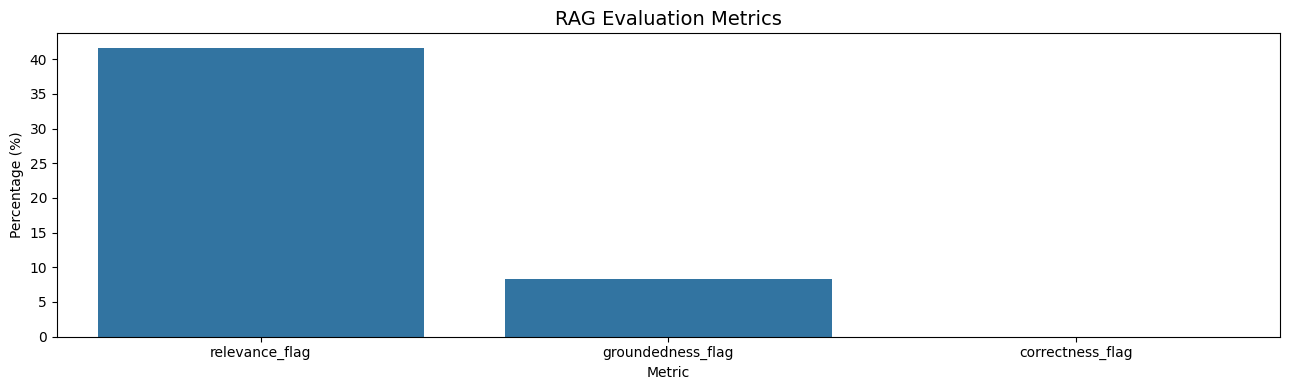

In [16]:
# Plot
fig, ax = plt.subplots(figsize=(13, 4))

sns.barplot(
    data=df_metrics,
    x="metric",
    y="value",
    ax=ax
)

# Formatting
ax.set_title("RAG Evaluation Metrics", fontsize=14)
ax.set_xlabel("Metric")
ax.set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

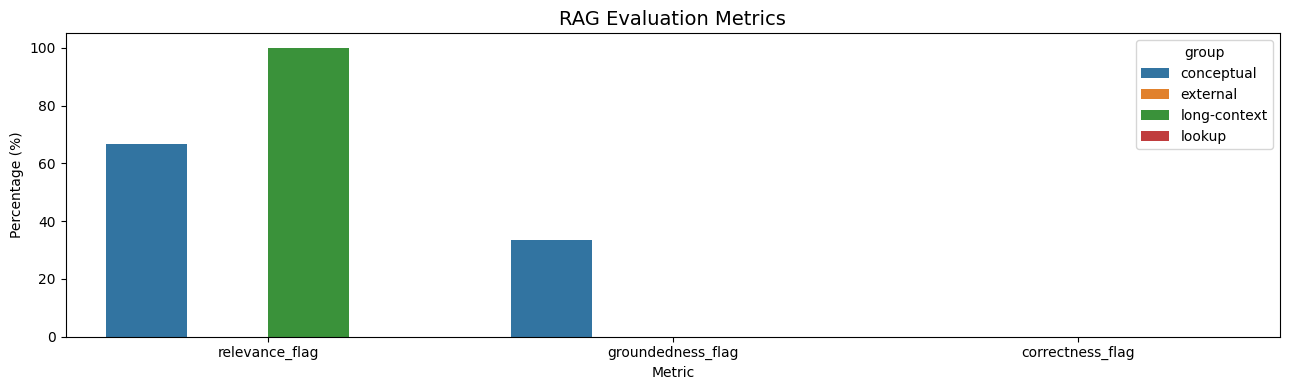

In [17]:
# Plot
fig, ax = plt.subplots(figsize=(13, 4))

sns.barplot(
    data=df_group_metrics,
    x="metric",
    y="percentage",
    hue='group',
    ax=ax
)

# Formatting
ax.set_title("RAG Evaluation Metrics", fontsize=14)
ax.set_xlabel("Metric")
ax.set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

### Failure Analysis

In [20]:
def view_result(
    df_evals: pd.DataFrame,
    question_id: int
) -> None:

    # filter row
    row = df_evals[
        df_evals["question_id"] == question_id
    ].iloc[0]

    # =====================================================
    # question
    # =====================================================

    print("=" * 80)
    print("QUESTION")
    print("=" * 80)

    print(row["question"])

    # =====================================================
    # group
    # =====================================================

    print("\n" + "=" * 80)
    print("GROUP")
    print("=" * 80)

    print(row["group"])

    # =====================================================
    # ground truth
    # =====================================================

    print("\n" + "=" * 80)
    print("GROUND TRUTH")
    print("=" * 80)

    print(row["ground_truth_answer"])

    # =====================================================
    # retrieved context
    # =====================================================

    print("\n" + "=" * 80)
    print("RETRIEVED CONTEXT")
    print("=" * 80)

    print(row["context"])

    # =====================================================
    # predicted answer
    # =====================================================

    print("\n" + "=" * 80)
    print("PREDICTED ANSWER")
    print("=" * 80)

    print(row["predicted_answer"])

    # =====================================================
    # self evaluation
    # =====================================================
    
    print("\n" + "=" * 80)
    print("SELF EVALUATION")
    print("=" * 80)
    
    print(f"Relevance Check    : {row['relevance_check']}")
    print(f"Plan               : {row['plan']}")
    print(f"Groundedness Check : {row['groundedness_check']}")
    print(f"Citation Check     : {row['citation_check']}")
    print(f"Usefulness Check   : {row['usefulness_check']}")
    print(f"LLM Error   : {row['llm_error']}")

    # =====================================================
    # evaluation
    # =====================================================

    print("\n" + "=" * 80)
    print("EVALUATION")
    print("=" * 80)

    print("\n[Relevance]")
    print(f"Think  : {row['relevance_think']}")
    print(f"Flag   : {row['relevance_flag']}")
    print(f"Reason : {row['relevance_reason']}")

    print("\n[Groundedness]")
    print(f"Think  : {row['groundedness_think']}")
    print(f"Flag   : {row['groundedness_flag']}")
    print(f"Reason : {row['groundedness_reason']}")

    print("\n[correctness]")
    print(f"Think : {row['correctness_think']}")
    print(f"Flag   : {row['correctness_flag']}")
    print(f"Reason : {row['correctness_reason']}")


    return

view_result(df_evals=df_evals, question_id=5) 

QUESTION
What is sampling in machine learning, why is it important, and what are its main types?

GROUP
conceptual

GROUND TRUTH
Sampling is important in machine learning for managing data size, reducing bias, and improving efficiency. The two main families are nonprobability sampling (e.g., convenience sampling) and random sampling (e.g., reservoir sampling and importance sampling). Effective sampling helps create more representative datasets while optimizing resource usage.

RETRIEVED CONTEXT
Chunk idx 1
Page number 313
Score: 1.1955

1Kunal Shah, “This Is What Makes SEO Important for Every Business, ” Entrepreneur India, May 11, 2020,
https://oreil.ly/teQlX.
2For a sneak peek into Tesla’s compute infrastructure for ML, I highly recommend watching the recording of
Tesla AI Day 2021 on Y ouTube.
3The definition for “reasonable scale” was inspired by Jacopo Tagliabue in his paper “Y ou Do Not Need a
Bigger Boat: Recommendations at Reasonable Scale in a (Mostly) Serverless and Open Stac